# M2 - LSTM Autoencoder + MC Dropout

---
## Section 1 - Setup

In [1]:
%pip install -q -r requirements.txt
# import subprocess, sys
# subprocess.check_call([sys.executable, "-m", "pip", "install",
#     "torch", "torchvision", "torchaudio",
#     "--index-url", "https://download.pytorch.org/whl/cu128",
#     "--force-reinstall"])



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os; os.makedirs("outputs", exist_ok=True)

In [3]:
import torch
print(torch.__version__)
x = torch.randn(2, 3).cuda()
print("CUDA OK:", x.device)



2.11.0+cu128
CUDA OK: cuda:0


In [4]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.get_device_capability())
print(torch.__file__)  # shows which torch is actually being used


2.11.0+cu128
12.8
(12, 0)
/usr/local/lib/python3.11/dist-packages/torch/__init__.py


In [5]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.get_device_capability())


2.11.0+cu128
12.8
(12, 0)


In [6]:
# ── Environment ───────────────────────────────────────────────────────────────
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ── Datasets ──────────────────────────────────────────────────────────────────
DATASETS = {
    "SKAB": {
        "npy_dir":     "npy_skab",
        "hf_dataset":  "skab-anomaly-detection",
        "window_size": 30,
        "n_features":  8,
    },
    "NAB": {
        "npy_dir":     "npy_nab",
        "hf_dataset":  "nab-anomaly-detection",
        "window_size": 50,
        "n_features":  1,
    },
}

# ── Hyperparameter grid (same space as M1 for fair comparison) ────────────────
# Full grid = 3×3×3 = 27 combos per dataset.
# Set MAX_HP_RUNS to an int to random-sample N configs instead (e.g. 9 on CPU).
HP_GRID = {
    "dropout_p":  [0.05, 0.10, 0.20],   # MC Dropout rate
    "latent_dim": [16, 32, 64],          # LSTM bottleneck (context vector size)
    "lr":         [5e-4, 1e-3, 2e-3],    # Adam learning rate
}
MAX_HP_RUNS = None   # None = full grid; int = random sample N combos

# ── LSTM architecture ─────────────────────────────────────────────────────────
# hidden_dim is fixed (not in HP grid) to keep search tractable.
# Increase for larger datasets or more complex patterns.
LSTM_HIDDEN_DIM = 64

# ── Fixed training hyperparameters ────────────────────────────────────────────
EPOCHS     = 100
BATCH_SIZE = 256
PATIENCE   = 10
T_MC       = 50    # stochastic forward passes at inference

# ── Checkpointing ─────────────────────────────────────────────────────────────
# During HP search → local saves only (0 HF commits).
# Winner pushed to HF once per dataset (≤ 5 commits total).
PUSH_TO_HUB            = True
MODEL_REPO_NAME        = "iot-ad-models"
CKPT_IMPROVEMENT_THR   = 0.10   # push when val drops ≥10% vs last HF push
MAX_INTERMEDIATE_CKPTS = 4      # +1 final = 5 HF commits max for winner run

# ── Evaluation ────────────────────────────────────────────────────────────────
THRESHOLD_PCT = 95

# ── W&B ───────────────────────────────────────────────────────────────────────
USE_WANDB     = True
WANDB_PROJECT = "iot-ad-mcd"
WANDB_ENTITY  = ""   # filled from os.getenv("WANDB_ENTITY") in next cell

# ── Misc ──────────────────────────────────────────────────────────────────────
SEED         = 42
OUTPUT_DIR   = "outputs"
CKPT_DIR     = "models/checkpoints"
RESULTS_FILE = f"{OUTPUT_DIR}/baseline_results.json"

In [7]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    f1_score, precision_recall_curve,
)
from huggingface_hub import HfApi, create_repo

# ── Credentials ───────────────────────────────────────────────────────────────
if IN_COLAB:
    try:
        from google.colab import userdata
        HF_USERNAME="ayyoubsoullami"
        HF_TOKEN=""
        WANDB_KEY="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"
        WANDB_ENTITY="soullamiayyoub"
    except Exception:
        HF_USERNAME="ayyoubsoullami"
        HF_TOKEN=""
        WANDB_KEY="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"
        WANDB_ENTITY="soullamiayyoub"
    if USE_WANDB:
        import wandb
        if WANDB_KEY:
            wandb.login(key=WANDB_KEY)
        else:
            wandb.login()
else:
    from dotenv import load_dotenv
    load_dotenv()
    HF_USERNAME="ayyoubsoullami"
    HF_TOKEN=""
    WANDB_KEY="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"
    WANDB_ENTITY="soullamiayyoub"
    if USE_WANDB:
        import wandb

if not HF_USERNAME or not HF_TOKEN:
    raise EnvironmentError(
        "HF_USERNAME or HF_TOKEN not found. "
        "Local: add to .env | Colab: add to Secrets panel."
    )

# ── Setup ─────────────────────────────────────────────────────────────────────
warnings.filterwarnings("ignore")
matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 10})
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CKPT_DIR,   exist_ok=True)

api           = HfApi()
MODEL_REPO_ID = f"{HF_USERNAME}/{MODEL_REPO_NAME}"

print(f"Environment  : {'Google Colab' if IN_COLAB else 'Local'}")
print(f"Device       : {device}")
print(f"HF_USERNAME  : {HF_USERNAME}")
print(f"Model repo   : {MODEL_REPO_ID}")
if USE_WANDB:
    _ent = WANDB_ENTITY or "(W&B default - set WANDB_ENTITY in .env if this errors)"
    print(f"W&B project  : {WANDB_PROJECT}  entity={_ent}")
else:
    print(f"W&B project  : (disabled)")
print("Imports OK")

Environment  : Local
Device       : cuda
HF_USERNAME  : ayyoubsoullami
Model repo   : ayyoubsoullami/iot-ad-models
W&B project  : iot-ad-mcd  entity=soullamiayyoub
Imports OK


In [8]:
try:
    create_repo(
        repo_id   = MODEL_REPO_ID,
        repo_type = "model",
        token     = HF_TOKEN,
        private   = False,
        exist_ok  = True,
    )
    print(f"HF model repo ready : https://huggingface.co/{MODEL_REPO_ID}")
except Exception as e:
    print(f"WARNING: could not verify HF repo - {e}")
    print("Checkpoints will be saved locally only.")

HF model repo ready : https://huggingface.co/ayyoubsoullami/iot-ad-models


---
## Section 2 - Data Loading

In [9]:
def _load_local(ds_name, cfg):
    npy_dir = cfg["npy_dir"]
    if not os.path.isdir(npy_dir):
        print(f"  WARNING: '{npy_dir}' not found - skipping {ds_name}.")
        return None
    arrays = {}
    for name in ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test"]:
        path = os.path.join(npy_dir, f"{name}.npy")
        if not os.path.exists(path):
            print(f"  WARNING: {path} missing - skipping {ds_name}.")
            return None
        arrays[name] = np.load(path)
    return arrays


def _load_from_hub(ds_name, cfg):
    from datasets import load_dataset as hf_load
    repo = f"{HF_USERNAME}/{cfg['hf_dataset']}"
    print(f"  Fetching {ds_name} from HF Hub: {repo} ...")
    try:
        ds = hf_load(repo)
    except Exception as e:
        print(f"  HF load failed ({e}) - falling back to local npy.")
        return _load_local(ds_name, cfg)
    n_feat = cfg["n_features"]
    def to_np(split):
        X = np.stack(
            [np.array(split[f"feature_{i}"]) for i in range(n_feat)], axis=-1
        ).astype(np.float32)
        y = np.array(split["label"], dtype=np.int8)
        return X, y
    X_train, y_train = to_np(ds["train"])
    X_val,   y_val   = to_np(ds["validation"])
    X_test,  y_test  = to_np(ds["test"])
    return dict(
        X_train=X_train, X_val=X_val, X_test=X_test,
        y_train=y_train, y_val=y_val, y_test=y_test,
    )


def load_dataset_arrays(ds_name, cfg):
    return _load_from_hub(ds_name, cfg) if IN_COLAB else _load_local(ds_name, cfg)


data = {}
for ds_name, cfg in DATASETS.items():
    print(f"\n{'='*50}\n{ds_name}")
    arr = load_dataset_arrays(ds_name, cfg)
    if arr is not None:
        data[ds_name] = arr
        for k, v in arr.items():
            print(f"  {k}: {v.shape}  dtype={v.dtype}")

print(f"\nDatasets loaded: {list(data.keys())}")


SKAB
  X_train: (23588, 30, 8)  dtype=float32
  X_val: (3345, 30, 8)  dtype=float32
  X_test: (19786, 30, 8)  dtype=float32
  y_train: (23588,)  dtype=int8
  y_val: (3345,)  dtype=int8
  y_test: (19786,)  dtype=int8

NAB
  X_train: (229577, 50, 1)  dtype=float32
  X_val: (30354, 50, 1)  dtype=float32
  X_test: (97101, 50, 1)  dtype=float32
  y_train: (229577,)  dtype=int8
  y_val: (30354,)  dtype=int8
  y_test: (97101,)  dtype=int8

Datasets loaded: ['SKAB', 'NAB']


---
## Section 3 - Model Architecture

In [10]:
class LSTMAE(nn.Module):
    """LSTM autoencoder with explicit Dropout layers for MC Dropout.

    dropout_p = 0.0  +  model.eval()   →  deterministic
    dropout_p > 0.0  +  model.train()  →  MC Dropout (M2)

    Architecture
    ────────────
    Encoder: LSTM → Dropout → Linear(hidden→latent)
    Decoder: Linear(latent→hidden) → Dropout → repeat → LSTM → Linear → Sigmoid
    """

    def __init__(self, n_features: int, hidden_dim: int = 64,
                 latent_dim: int = 32, dropout_p: float = 0.05):
        super().__init__()
        self.window_size = None   # set dynamically at first forward pass

        # Encoder
        self.enc_lstm = nn.LSTM(n_features, hidden_dim, batch_first=True, num_layers=1)
        self.enc_drop = nn.Dropout(dropout_p)
        self.enc_fc   = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.dec_fc   = nn.Linear(latent_dim, hidden_dim)
        self.dec_drop = nn.Dropout(dropout_p)
        self.dec_lstm = nn.LSTM(hidden_dim, hidden_dim, batch_first=True, num_layers=1)
        self.dec_out  = nn.Linear(hidden_dim, n_features)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, window, n_features)
        T = x.size(1)

        # Encode - take last hidden state as context vector
        _, (h_n, _) = self.enc_lstm(x)          # h_n: (1, batch, hidden)
        h = h_n.squeeze(0)                       # (batch, hidden)
        h = self.enc_drop(h)
        z = self.enc_fc(h)                       # (batch, latent)

        # Decode - repeat context over time steps
        d = self.dec_fc(z)                       # (batch, hidden)
        d = self.dec_drop(d)
        d = d.unsqueeze(1).expand(-1, T, -1)     # (batch, window, hidden)
        out, _ = self.dec_lstm(d)                # (batch, window, hidden)
        out = self.dec_out(out)                  # (batch, window, n_features)
        return self.sigmoid(out)

---
## Section 4 - Training & Checkpointing Helpers

In [11]:
def push_checkpoint(model, filename, commit_msg):
    """Save model state locally; optionally upload to HF Hub."""
    local_path = os.path.join(CKPT_DIR, filename)
    torch.save(model.state_dict(), local_path)
    if not PUSH_TO_HUB:
        return
    try:
        api.upload_file(
            path_or_fileobj = local_path,
            path_in_repo    = f"checkpoints/{filename}",
            repo_id         = MODEL_REPO_ID,
            repo_type       = "model",
            token           = HF_TOKEN,
            commit_message  = commit_msg,
        )
        print(f"      ↑ HF: checkpoints/{filename}")
    except Exception as e:
        print(f"      ⚠ HF push failed ({filename}): {e}")

In [12]:
def train_mcd(model, X_train, X_val, run_label, hp, wandb_run=None,
              push_to_hf=False):
    """Train LSTM AE with MC Dropout.

    Input arrays are kept 3-D (batch, window, features) - NOT flattened.
    Reconstruction error is MSE averaged over both time and feature dims.

    Parameters
    ----------
    hp         : dict {dropout_p, latent_dim, lr}
    push_to_hf : False during HP search (local only); True for winner run.

    Returns
    -------
    (model, train_losses, val_losses, best_val_loss, local_ckpt_path)
    """
    dropout_p  = hp["dropout_p"]
    latent_dim = hp["latent_dim"]
    lr         = hp["lr"]
    hp_tag     = f"dp{dropout_p}_ld{latent_dim}_lr{lr:.0e}"

    # 3-D tensors - no reshape
    t_tens = torch.from_numpy(X_train).float()
    v_tens = torch.from_numpy(X_val).float()
    t_dl   = DataLoader(TensorDataset(t_tens), batch_size=BATCH_SIZE, shuffle=True)
    v_dl   = DataLoader(TensorDataset(v_tens), batch_size=BATCH_SIZE)

    opt  = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.MSELoss()

    best_val, best_state, patience_ctr = float("inf"), None, 0
    train_losses, val_losses            = [], []
    last_pushed_val = float("inf")
    n_intermediate  = 0

    for epoch in range(EPOCHS):
        # ── train (dropout active) ─────────────────────────────────────────────
        model.train()
        ep_loss = 0.0
        for (xb,) in t_dl:
            xb   = xb.to(device)
            loss = crit(model(xb), xb)
            opt.zero_grad(); loss.backward(); opt.step()
            ep_loss += loss.item() * len(xb)
        tl = ep_loss / len(t_tens)

        # ── validate (dropout off - deterministic) ─────────────────────────────
        model.eval()
        with torch.no_grad():
            vl = sum(
                crit(model(xb.to(device)), xb.to(device)).item() * len(xb)
                for (xb,) in v_dl
            ) / len(v_tens)

        train_losses.append(tl)
        val_losses.append(vl)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"    [{run_label}|{hp_tag}] ep {epoch+1:3d}/{EPOCHS}"
                  f"  train={tl:.5f}  val={vl:.5f}  best={best_val:.5f}")

        if wandb_run:
            wandb_run.log({"train_loss": tl, "val_loss": vl,
                           "epoch": epoch + 1, "best_val": best_val})

        # ── track best in RAM ──────────────────────────────────────────────────
        if vl < best_val - 1e-6:
            best_val     = vl
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1

        # ── smart HF intermediate checkpoint (winner run only) ─────────────────
        if push_to_hf and n_intermediate < MAX_INTERMEDIATE_CKPTS:
            rel_drop      = (last_pushed_val - vl) / (last_pushed_val + 1e-9)
            cond_big_drop = rel_drop >= CKPT_IMPROVEMENT_THR
            cond_overfit  = patience_ctr == 1 and epoch > 0
            if cond_big_drop or cond_overfit:
                reason = "big_drop" if cond_big_drop else "overfit_signal"
                push_checkpoint(
                    model,
                    f"{run_label}_{hp_tag}_ep{epoch+1:03d}.pt",
                    f"[{reason}] {run_label} {hp_tag} ep={epoch+1} val={vl:.6f}",
                )
                last_pushed_val = vl
                n_intermediate += 1

        if patience_ctr >= PATIENCE:
            print(f"    [{run_label}|{hp_tag}] Early stop ep {epoch + 1}"
                  f"  best val={best_val:.5f}")
            break

    # ── restore best weights ───────────────────────────────────────────────────
    model.load_state_dict(best_state)

    # ── save locally (always) ─────────────────────────────────────────────────
    local_path = os.path.join(CKPT_DIR, f"{run_label}_{hp_tag}.pt")
    torch.save(model.state_dict(), local_path)

    # ── push to HF (winner run only) ──────────────────────────────────────────
    if push_to_hf:
        push_checkpoint(
            model,
            f"{run_label}_{hp_tag}_best.pt",
            f"Best {run_label} {hp_tag} val={best_val:.6f}"
            f" | {n_intermediate} intermediate ckpts",
        )
        print(f"    [{run_label}|{hp_tag}] Done - "
              f"{n_intermediate} intermediate + 1 final = "
              f"{n_intermediate + 1} HF commits.")
    else:
        print(f"    [{run_label}|{hp_tag}] Done - "
              f"val={best_val:.5f}  saved locally → {local_path}")

    return model, train_losses, val_losses, best_val, local_path

In [13]:
def mcd_scores(model, X, T=T_MC, batch_size=512):
    """T stochastic forward passes with dropout active.

    Input X shape: (n_windows, window_size, n_features)  - NOT flattened.
    Error per window = MSE averaged over (window, features) dims.

    Returns dict:
      'mean'  (n_windows,)   - point-estimate anomaly score
      'std'   (n_windows,)   - uncertainty (spread across T passes)
      'all'   (T, n_windows) - raw per-pass errors
    """
    model.train()   # ← keep dropout ACTIVE
    X_t = torch.from_numpy(X).float()   # (N, window, features) - no reshape

    pass_errors = []
    with torch.no_grad():
        for t in range(T):
            errs = []
            dl   = DataLoader(TensorDataset(X_t), batch_size=batch_size)
            for (xb,) in dl:
                xb  = xb.to(device)
                # MSE over (window, features) → scalar per window
                err = ((xb - model(xb)) ** 2).mean(dim=(1, 2))
                errs.append(err.cpu().numpy())
            pass_errors.append(np.concatenate(errs))
            if (t + 1) % 10 == 0:
                print(f"  MC pass {t + 1}/{T}", end="\r")

    all_errors = np.stack(pass_errors)   # (T, n_windows)
    print(f"  MC Dropout: {T} passes complete.          ")
    return {
        "mean": all_errors.mean(axis=0),
        "std":  all_errors.std(axis=0),
        "all":  all_errors,
    }

---
## Section 5 - Hyperparameter Search

In [14]:
import itertools, random as _random

def _build_hp_combos():
    combos = [
        {"dropout_p": dp, "latent_dim": ld, "lr": lr}
        for dp, ld, lr in itertools.product(
            HP_GRID["dropout_p"], HP_GRID["latent_dim"], HP_GRID["lr"]
        )
    ]
    if MAX_HP_RUNS is not None and MAX_HP_RUNS < len(combos):
        _random.seed(SEED)
        combos = _random.sample(combos, MAX_HP_RUNS)
    return combos


def _hp_key(hp):
    return f"dp{hp['dropout_p']}_ld{hp['latent_dim']}_lr{hp['lr']:.0e}"


sweep_results = {}
best_models   = {}

hp_combos = _build_hp_combos()
print(f"HP search: {len(hp_combos)} combos per dataset "
      f"({'full grid' if MAX_HP_RUNS is None else f'random sample of {MAX_HP_RUNS}'})")
print(f"Grid: dropout_p={HP_GRID['dropout_p']}  "
      f"latent_dim={HP_GRID['latent_dim']}  lr={HP_GRID['lr']}")
print(f"LSTM hidden_dim fixed at {LSTM_HIDDEN_DIM}\n")

for ds_name, cfg in DATASETS.items():
    if ds_name not in data:
        print(f"Skipping {ds_name} - data not loaded.")
        continue

    arr       = data[ds_name]
    X_train   = arr["X_train"]
    X_val     = arr["X_val"]
    n_features = cfg["n_features"]
    run_label  = f"lstm_ae_mcd_{ds_name.lower()}"

    print(f"\n{'='*70}")
    print(f"  {ds_name}   shape={X_train.shape}   "
          f"hidden_dim={LSTM_HIDDEN_DIM}   {len(hp_combos)} combos")
    print(f"{'='*70}")

    # ── load partial results (crash recovery) ─────────────────────────────────
    partial_file = f"{OUTPUT_DIR}/hp_partial_{ds_name.lower()}_lstm.json"
    try:
        with open(partial_file) as f:
            partial = json.load(f)
        sweep_results[ds_name] = partial
        print(f"  Resumed from {partial_file}: "
              f"{len(partial)}/{len(hp_combos)} combos already done.\n")
    except FileNotFoundError:
        sweep_results[ds_name] = {}

    for i, hp in enumerate(hp_combos):
        key = _hp_key(hp)
        local_ckpt = os.path.join(CKPT_DIR, f"{run_label}_{key}.pt")

        if key in sweep_results[ds_name] and os.path.exists(local_ckpt):
            vl = sweep_results[ds_name][key]["val_loss"]
            print(f"  [{i+1:2d}/{len(hp_combos)}] ✓ (cached)  {key}  val={vl:.6f}")
            continue

        print(f"\n  [{i+1:2d}/{len(hp_combos)}]  {key}")

        wandb_run = None
        if USE_WANDB:
            try:
                wandb_run = wandb.init(
                    project = WANDB_PROJECT,
                    entity  = WANDB_ENTITY or None,
                    name    = f"M2_{ds_name}_{key}",
                    config  = {
                        "method":      "LSTM_AE_MCD",
                        "dataset":     ds_name,
                        **hp,
                        "hidden_dim":  LSTM_HIDDEN_DIM,
                        "T_MC":        T_MC,
                        "epochs":      EPOCHS,
                        "patience":    PATIENCE,
                        "batch_size":  BATCH_SIZE,
                        "window_size": cfg["window_size"],
                        "n_features":  cfg["n_features"],
                        "in_colab":    IN_COLAB,
                    },
                    reinit = True,
                )
            except Exception as e:
                print(f"  ⚠ W&B init failed ({e}) - continuing without tracking.")
                wandb_run = None

        model = LSTMAE(n_features, LSTM_HIDDEN_DIM, hp["latent_dim"],
                       hp["dropout_p"]).to(device)
        model, t_losses, v_losses, best_val, ckpt_path = train_mcd(
            model, X_train, X_val, run_label, hp, wandb_run,
            push_to_hf=False,
        )

        if wandb_run:
            wandb_run.summary["best_val_loss"] = best_val
            wandb_run.summary["n_epochs_run"]  = len(t_losses)
            wandb_run.finish()

        sweep_results[ds_name][key] = {
            "hp":           hp,
            "val_loss":     best_val,
            "train_losses": t_losses,
            "val_losses":   v_losses,
            "local_ckpt":   ckpt_path,
        }

        with open(partial_file, "w") as f:
            json.dump(sweep_results[ds_name], f, indent=2)

        print(f"  → val={best_val:.6f}  ({len(t_losses)} epochs)  "
              f"[{i+1}/{len(hp_combos)} done]")

    # ── pick best ─────────────────────────────────────────────────────────────
    best_key   = min(sweep_results[ds_name],
                     key=lambda k: sweep_results[ds_name][k]["val_loss"])
    best_entry = sweep_results[ds_name][best_key]
    best_hp    = best_entry["hp"]

    print(f"\n  {'─'*60}")
    print(f"  ✅ Best combo : {best_key}")
    print(f"     val_loss   : {best_entry['val_loss']:.6f}")

    best_model = LSTMAE(n_features, LSTM_HIDDEN_DIM, best_hp["latent_dim"],
                        best_hp["dropout_p"]).to(device)
    best_model.load_state_dict(
        torch.load(best_entry["local_ckpt"], map_location=device)
    )
    best_model.eval()

    print(f"  Pushing winner to HF Hub ...")
    final_name = f"lstm_ae_mcd_{ds_name.lower()}_final.pt"
    push_checkpoint(
        best_model, final_name,
        f"M2 winner {ds_name} | {best_key} | val={best_entry['val_loss']:.6f}",
    )

    best_models[ds_name] = {
        "model":        best_model,
        "hp":           best_hp,
        "val_loss":     best_entry["val_loss"],
        "train_losses": best_entry["train_losses"],
        "val_losses":   best_entry["val_losses"],
    }
    print(f"  HF Hub → {MODEL_REPO_ID}/checkpoints/{final_name}")

print("\n\n✅ HP search complete.")

HP search: 27 combos per dataset (full grid)
Grid: dropout_p=[0.05, 0.1, 0.2]  latent_dim=[16, 32, 64]  lr=[0.0005, 0.001, 0.002]
LSTM hidden_dim fixed at 64


  SKAB   shape=(23588, 30, 8)   hidden_dim=64   27 combos

  [ 1/27]  dp0.05_ld16_lr5e-04


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: eyyoub (eyyoub-um) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


  ⚠ W&B init failed (entity soullamiayyoub not found during upsertBucket) - continuing without tracking.
    [lstm_ae_mcd_skab|dp0.05_ld16_lr5e-04] ep   1/100  train=0.03865  val=0.02682  best=inf
    [lstm_ae_mcd_skab|dp0.05_ld16_lr5e-04] ep  10/100  train=0.01108  val=0.00963  best=0.00807
    [lstm_ae_mcd_skab|dp0.05_ld16_lr5e-04] ep  20/100  train=0.00924  val=0.00786  best=0.00784
    [lstm_ae_mcd_skab|dp0.05_ld16_lr5e-04] ep  30/100  train=0.00911  val=0.00776  best=0.00781
    [lstm_ae_mcd_skab|dp0.05_ld16_lr5e-04] ep  40/100  train=0.00904  val=0.00771  best=0.00773
    [lstm_ae_mcd_skab|dp0.05_ld16_lr5e-04] ep  50/100  train=0.00889  val=0.00768  best=0.00767
    [lstm_ae_mcd_skab|dp0.05_ld16_lr5e-04] ep  60/100  train=0.00887  val=0.00769  best=0.00765
    [lstm_ae_mcd_skab|dp0.05_ld16_lr5e-04] Early stop ep 64  best val=0.00765
    [lstm_ae_mcd_skab|dp0.05_ld16_lr5e-04] Done - val=0.00765  saved locally → models/checkpoints/lstm_ae_mcd_skab_dp0.05_ld16_lr5e-04.pt
  → val=0.0

  ⚠ W&B init failed (entity soullamiayyoub not found during upsertBucket) - continuing without tracking.
    [lstm_ae_mcd_skab|dp0.05_ld16_lr1e-03] ep   1/100  train=0.02914  val=0.02425  best=inf
    [lstm_ae_mcd_skab|dp0.05_ld16_lr1e-03] ep  10/100  train=0.00917  val=0.00794  best=0.00809
    [lstm_ae_mcd_skab|dp0.05_ld16_lr1e-03] ep  20/100  train=0.00958  val=0.00781  best=0.00778
    [lstm_ae_mcd_skab|dp0.05_ld16_lr1e-03] ep  30/100  train=0.00887  val=0.00776  best=0.00775
    [lstm_ae_mcd_skab|dp0.05_ld16_lr1e-03] ep  40/100  train=0.00884  val=0.00768  best=0.00768
    [lstm_ae_mcd_skab|dp0.05_ld16_lr1e-03] ep  50/100  train=0.00878  val=0.00758  best=0.00761
    [lstm_ae_mcd_skab|dp0.05_ld16_lr1e-03] ep  60/100  train=0.00874  val=0.00746  best=0.00749
    [lstm_ae_mcd_skab|dp0.05_ld16_lr1e-03] ep  70/100  train=0.00873  val=0.00738  best=0.00740
    [lstm_ae_mcd_skab|dp0.05_ld16_lr1e-03] ep  80/100  train=0.00868  val=0.00743  best=0.00738
    [lstm_ae_mcd_skab|dp0.05_ld16_l

  ⚠ W&B init failed (entity soullamiayyoub not found during upsertBucket) - continuing without tracking.
    [lstm_ae_mcd_skab|dp0.05_ld16_lr2e-03] ep   1/100  train=0.02366  val=0.01055  best=inf
    [lstm_ae_mcd_skab|dp0.05_ld16_lr2e-03] ep  10/100  train=0.00923  val=0.00795  best=0.00770
    [lstm_ae_mcd_skab|dp0.05_ld16_lr2e-03] Early stop ep 16  best val=0.00770
    [lstm_ae_mcd_skab|dp0.05_ld16_lr2e-03] Done - val=0.00770  saved locally → models/checkpoints/lstm_ae_mcd_skab_dp0.05_ld16_lr2e-03.pt
  → val=0.007697  (16 epochs)  [3/27 done]

  [ 4/27]  dp0.05_ld32_lr5e-04


...

  ⚠ W&B init failed (entity soullamiayyoub not found during upsertBucket) - continuing without tracking.
    [lstm_ae_mcd_nab|dp0.2_ld64_lr1e-03] ep   1/100  train=0.01773  val=0.01192  best=inf
    [lstm_ae_mcd_nab|dp0.2_ld64_lr1e-03] ep  10/100  train=0.00721  val=0.00609  best=0.00655
    [lstm_ae_mcd_nab|dp0.2_ld64_lr1e-03] ep  20/100  train=0.00510  val=0.00400  best=0.00403
    [lstm_ae_mcd_nab|dp0.2_ld64_lr1e-03] ep  60/100  train=0.00411  val=0.00318  best=0.00317
    [lstm_ae_mcd_nab|dp0.2_ld64_lr1e-03] ep  70/100  train=0.00406  val=0.00310  best=0.00313
    [lstm_ae_mcd_nab|dp0.2_ld64_lr1e-03] ep  80/100  train=0.00373  val=0.00297  best=0.00294
    [lstm_ae_mcd_nab|dp0.2_ld64_lr1e-03] Early stop ep 86  best val=0.00294
    [lstm_ae_mcd_nab|dp0.2_ld64_lr1e-03] Done - val=0.00294  saved locally → models/checkpoints/lstm_ae_mcd_nab_dp0.2_ld64_lr1e-03.pt
  → val=0.002941  (86 epochs)  [26/27 done]

  [27/27]  dp0.2_ld64_lr2e-03


  ⚠ W&B init failed (entity soullamiayyoub not found during upsertBucket) - continuing without tracking.
    [lstm_ae_mcd_nab|dp0.2_ld64_lr2e-03] ep   1/100  train=0.01629  val=0.01216  best=inf
    [lstm_ae_mcd_nab|dp0.2_ld64_lr2e-03] ep  10/100  train=0.00632  val=0.00520  best=0.00557
    [lstm_ae_mcd_nab|dp0.2_ld64_lr2e-03] ep  20/100  train=0.00492  val=0.00398  best=0.00397
    [lstm_ae_mcd_nab|dp0.2_ld64_lr2e-03] ep  30/100  train=0.00485  val=0.00367  best=0.00370
    [lstm_ae_mcd_nab|dp0.2_ld64_lr2e-03] ep  40/100  train=0.00465  val=0.00400  best=0.00354
    [lstm_ae_mcd_nab|dp0.2_ld64_lr2e-03] ep  50/100  train=0.00434  val=0.00352  best=0.00340
    [lstm_ae_mcd_nab|dp0.2_ld64_lr2e-03] ep  60/100  train=0.00404  val=0.00324  best=0.00336
    [lstm_ae_mcd_nab|dp0.2_ld64_lr2e-03] ep  70/100  train=0.00406  val=0.00338  best=0.00322
    [lstm_ae_mcd_nab|dp0.2_ld64_lr2e-03] Early stop ep 75  best val=0.00322
    [lstm_ae_mcd_nab|dp0.2_ld64_lr2e-03] Done - val=0.00322  saved loca

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

      ↑ HF: checkpoints/lstm_ae_mcd_nab_final.pt
  HF Hub → ayyoubsoullami/iot-ad-models/checkpoints/lstm_ae_mcd_nab_final.pt


✅ HP search complete.



NAB - HP search results (27 combos)
  Rank   dropout_p  latent_dim        lr      val_loss   epochs
  ────────────────────────────────────────────────────────────
     1        0.05          32     2e-03      0.002092      100 ← best
     2        0.05          64     1e-03      0.002236      100 ← top3
     3        0.05          32     1e-03      0.002253      100 ← top3
     4        0.05          16     2e-03      0.002273      100
     5        0.05          16     1e-03      0.002340      100
     6        0.05          64     2e-03      0.002362       65
     7        0.10          32     1e-03      0.002474      100
     8        0.10          32     2e-03      0.002510      100
     9        0.10          64     1e-03      0.002550      100
    10        0.05          64     5e-04      0.002607      100
    11        0.05          16     5e-04      0.002619      100
    12        0.10          64     5e-04      0.002769      100
    13        0.10          16     5e-04      0

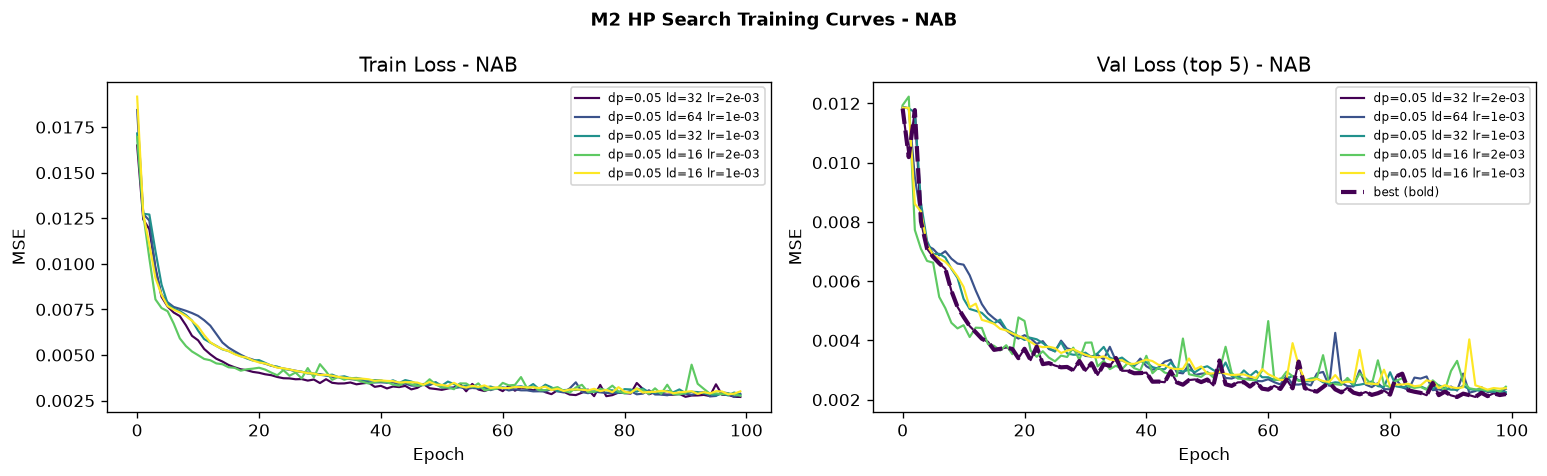

Saved outputs/m2_hp_curves_nab.png

SKAB - HP search results (27 combos)
  Rank   dropout_p  latent_dim        lr      val_loss   epochs
  ────────────────────────────────────────────────────────────
     1        0.05          16     1e-03      0.007379       80 ← best
     2        0.05          32     2e-03      0.007592       22 ← top3
     3        0.10          16     1e-03      0.007610       42 ← top3
     4        0.10          16     2e-03      0.007632       63
     5        0.10          64     5e-04      0.007634       54
     6        0.10          64     1e-03      0.007636       52
     7        0.10          32     2e-03      0.007637       30
     8        0.20          32     2e-03      0.007640       34
     9        0.05          16     5e-04      0.007646       64
    10        0.20          32     1e-03      0.007646       32
    11        0.05          32     5e-04      0.007649       53
    12        0.05          64     2e-03      0.007650       25
    13     

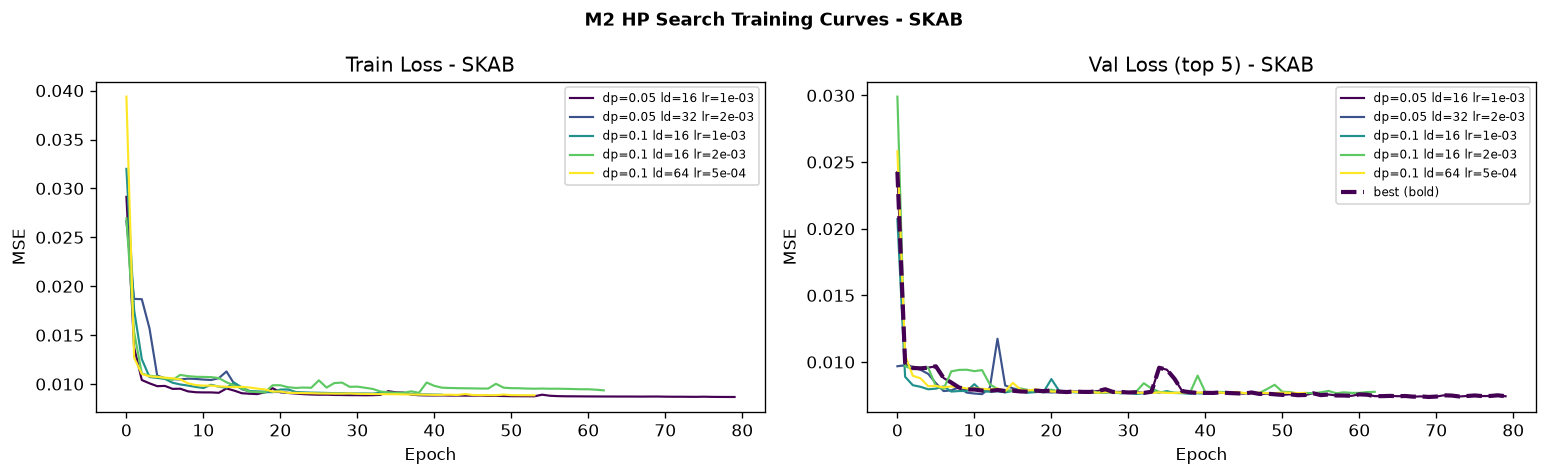

Saved outputs/m2_hp_curves_skab.png


In [15]:
for ds_name in sorted(sweep_results.keys()):
    res    = sweep_results[ds_name]
    ranked = sorted(res.items(), key=lambda kv: kv[1]["val_loss"])

    print(f"\n{ds_name} - HP search results ({len(ranked)} combos)")
    print(f"  {'Rank':>4}  {'dropout_p':>10}  {'latent_dim':>10}  {'lr':>8}  "
          f"{'val_loss':>12}  {'epochs':>7}")
    print(f"  {'─'*60}")
    for rank, (key, entry) in enumerate(ranked, 1):
        hp = entry["hp"]
        n  = len(entry["val_losses"])
        marker = " ← best" if rank == 1 else (" ← top3" if rank <= 3 else "")
        print(f"  {rank:>4}  {hp['dropout_p']:>10.2f}  {hp['latent_dim']:>10d}  "
              f"{hp['lr']:>8.0e}  {entry['val_loss']:>12.6f}  {n:>7}{marker}")

    # top-5 curves
    top5   = ranked[:5]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    cmap   = plt.cm.viridis
    colors = [cmap(i / max(len(top5) - 1, 1)) for i in range(len(top5))]

    for (key, entry), color in zip(top5, colors):
        hp    = entry["hp"]
        label = f"dp={hp['dropout_p']} ld={hp['latent_dim']} lr={hp['lr']:.0e}"
        axes[0].plot(entry["train_losses"], color=color, lw=1.3, label=label)
        axes[1].plot(entry["val_losses"],   color=color, lw=1.3, label=label)

    axes[1].plot(ranked[0][1]["val_losses"], color=colors[0], lw=2.5, ls="--",
                 label="best (bold)")

    for ax, title in zip(axes, ["Train Loss", "Val Loss (top 5)"]):
        ax.set_title(f"{title} - {ds_name}")
        ax.set_xlabel("Epoch"); ax.set_ylabel("MSE")
        ax.legend(fontsize=7, loc="upper right")

    fig.suptitle(f"M2 HP Search Training Curves - {ds_name}",
                 fontsize=11, fontweight="bold")
    plt.tight_layout()
    path = f"{OUTPUT_DIR}/m2_hp_curves_{ds_name.lower()}.png"
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved {path}")

In [16]:
print("=" * 70)
print("  M2 HP SEARCH SUMMARY - best combo per dataset")
print("=" * 70)
for ds_name in sorted(best_models.keys()):
    bm = best_models[ds_name]
    hp = bm["hp"]
    print(f"\n  {ds_name}")
    print(f"  Best HP : dropout_p={hp['dropout_p']}  "
          f"latent_dim={hp['latent_dim']}  lr={hp['lr']:.0e}  "
          f"hidden_dim={LSTM_HIDDEN_DIM}")
    print(f"  Val loss: {bm['val_loss']:.6f}  ({len(bm['val_losses'])} epochs)")
print("\n" + "=" * 70)

  M2 HP SEARCH SUMMARY - best combo per dataset

  NAB
  Best HP : dropout_p=0.05  latent_dim=32  lr=2e-03  hidden_dim=64
  Val loss: 0.002092  (100 epochs)

  SKAB
  Best HP : dropout_p=0.05  latent_dim=16  lr=1e-03  hidden_dim=64
  Val loss: 0.007379  (80 epochs)



---
## Section 6 - MC Dropout Inference

In [17]:
mcd_results = {}

for ds_name, bm in best_models.items():
    hp    = bm["hp"]
    model = bm["model"]

    print(f"\n{'='*55}")
    print(f"{ds_name} - MC Dropout  T={T_MC}  "
          f"dropout_p={hp['dropout_p']}  latent_dim={hp['latent_dim']}  "
          f"lr={hp['lr']:.0e}")

    arr = data[ds_name]
    print("  Val inference ...")
    val_mcd  = mcd_scores(model, arr["X_val"],  T=T_MC)
    print("  Test inference ...")
    test_mcd = mcd_scores(model, arr["X_test"], T=T_MC)

    mcd_results[ds_name] = {
        "hp":           hp,
        "val_mcd":      val_mcd,
        "test_mcd":     test_mcd,
        "train_losses": bm["train_losses"],
        "val_losses":   bm["val_losses"],
    }
    print(f"  val  mean score : {val_mcd['mean'].mean():.5f} ± {val_mcd['mean'].std():.5f}")
    print(f"  test mean score : {test_mcd['mean'].mean():.5f} ± {test_mcd['mean'].std():.5f}")
    print(f"  test uncertainty: {test_mcd['std'].mean():.5f} (mean std across windows)")


SKAB - MC Dropout  T=50  dropout_p=0.05  latent_dim=16  lr=1e-03
  Val inference ...
  MC Dropout: 50 passes complete.          
  Test inference ...
  MC Dropout: 50 passes complete.          
  val  mean score : 0.00740 ± 0.00144
  test mean score : 0.01583 ± 0.02766
  test uncertainty: 0.00030 (mean std across windows)

NAB - MC Dropout  T=50  dropout_p=0.05  latent_dim=32  lr=2e-03
  Val inference ...
  MC Dropout: 50 passes complete.          
  Test inference ...
  MC Dropout: 50 passes complete.          
  val  mean score : 0.00234 ± 0.00705
  test mean score : 0.17191 ± 2.39978
  test uncertainty: 0.00776 (mean std across windows)


---
## Section 7 - Evaluation

In [18]:
def compute_metrics(y_true, test_scores, val_scores, thr_pct=THRESHOLD_PCT):
    auc_pr = float(average_precision_score(y_true, test_scores))
    auroc  = float(roc_auc_score(y_true, test_scores))
    thr    = float(np.percentile(val_scores, thr_pct))
    f1     = float(f1_score(y_true, (test_scores >= thr).astype(int),
                            zero_division=0))
    return {
        "auc_pr":    round(auc_pr, 4),
        "auroc":     round(auroc,  4),
        "f1":        round(f1,     4),
        "threshold": thr,
    }


def compute_uncertainty_auroc(y_true, uncertainty_scores):
    mask = ~np.isnan(uncertainty_scores)
    if mask.sum() < 10:
        return float("nan")
    return round(float(roc_auc_score(y_true[mask], uncertainty_scores[mask])), 4)


for ds_name, res in mcd_results.items():
    y_test    = data[ds_name]["y_test"]
    det_m     = compute_metrics(
        y_test, res["test_mcd"]["mean"], res["val_mcd"]["mean"]
    )
    auroc_unc = compute_uncertainty_auroc(y_test, res["test_mcd"]["std"])
    mcd_results[ds_name]["det_metrics"] = det_m
    mcd_results[ds_name]["auroc_unc"]   = auroc_unc

    hp = res["hp"]
    print(f"{ds_name}  dropout_p={hp['dropout_p']}  "
          f"latent_dim={hp['latent_dim']}  lr={hp['lr']:.0e}")
    print(f"  Detection:   AUC-PR={det_m['auc_pr']:.4f}  "
          f"AUROC={det_m['auroc']:.4f}  F1={det_m['f1']:.4f}")
    print(f"  Uncertainty: AUROC(std)={auroc_unc:.4f}\n")

SKAB  dropout_p=0.05  latent_dim=16  lr=1e-03
  Detection:   AUC-PR=0.7632  AUROC=0.5455  F1=0.4139
  Uncertainty: AUROC(std)=0.4648

NAB  dropout_p=0.05  latent_dim=32  lr=2e-03
  Detection:   AUC-PR=0.4663  AUROC=0.5992  F1=0.3164
  Uncertainty: AUROC(std)=0.5858



In [19]:
# Comparison table: B3 (det.) · M1 (Dense AE + MCD) · M2 (LSTM AE + MCD)
try:
    with open(RESULTS_FILE) as f:
        baseline_results = json.load(f)
    print(f"Loaded baseline results from {RESULTS_FILE}")
except FileNotFoundError:
    baseline_results = {}
    print("WARNING: baseline_results.json not found - B3/M1 columns will be empty.")

rows = []
for ds_name in sorted(data.keys()):
    # B3
    b3 = baseline_results.get(ds_name, {}).get("B3_denseae", {}).get("metrics", {})
    rows.append({
        "Dataset": ds_name, "Method": "B3 - Dense AE (det.)",
        "AUC-PR": b3.get("auc_pr", float("nan")),
        "AUROC":  b3.get("auroc",  float("nan")),
        "F1":     b3.get("f1",     float("nan")),
        "AUROC(unc)": float("nan"),
    })
    # M1
    m1 = baseline_results.get(ds_name, {}).get("M1_dense_mcd", {}).get("metrics", {})
    m1_hp = baseline_results.get(ds_name, {}).get("M1_dense_mcd", {}).get("hp", {})
    m1_hp_str = (f"dp={m1_hp.get('dropout_p','?')} "
                 f"ld={m1_hp.get('latent_dim','?')} "
                 f"lr={m1_hp.get('lr',0):.0e}") if m1_hp else "-"
    rows.append({
        "Dataset": ds_name, "Method": f"M1 - Dense AE + MCD  [{m1_hp_str}]",
        "AUC-PR": m1.get("auc_pr",  float("nan")),
        "AUROC":  m1.get("auroc",   float("nan")),
        "F1":     m1.get("f1",      float("nan")),
        "AUROC(unc)": m1.get("auroc_unc", float("nan")),
    })
    # M2
    m2  = mcd_results.get(ds_name, {})
    dm  = m2.get("det_metrics", {})
    hp  = m2.get("hp", {})
    hp_str = (f"dp={hp.get('dropout_p','?')} "
              f"ld={hp.get('latent_dim','?')} "
              f"lr={hp.get('lr',0):.0e}") if hp else "-"
    rows.append({
        "Dataset": ds_name, "Method": f"M2 - LSTM AE + MCD   [{hp_str}]",
        "AUC-PR": dm.get("auc_pr",  float("nan")),
        "AUROC":  dm.get("auroc",   float("nan")),
        "F1":     dm.get("f1",      float("nan")),
        "AUROC(unc)": m2.get("auroc_unc", float("nan")),
    })

comp_df = pd.DataFrame(rows).set_index(["Dataset", "Method"])
print(comp_df.to_string())
print()
display(
    comp_df.style
    .background_gradient(subset=["AUC-PR"],    cmap="Greens")
    .background_gradient(subset=["AUROC"],      cmap="Blues")
    .background_gradient(subset=["F1"],         cmap="Oranges")
    .background_gradient(subset=["AUROC(unc)"], cmap="Purples")
    .format("{:.4f}", subset=["AUC-PR","AUROC","F1","AUROC(unc)"], na_rep="-")
)

Loaded baseline results from outputs/baseline_results.json
                                                       AUC-PR   AUROC      F1  AUROC(unc)
Dataset Method                                                                           
NAB     B3 - Dense AE (det.)                           0.4672  0.6012  0.3183         NaN
        M1 - Dense AE + MCD  [dp=0.05 ld=32 lr=2e-03]  0.4631  0.5934  0.3182      0.5835
        M2 - LSTM AE + MCD   [dp=0.05 ld=32 lr=2e-03]  0.4663  0.5992  0.3164      0.5858
SKAB    B3 - Dense AE (det.)                           0.7960  0.6105  0.3914         NaN
        M1 - Dense AE + MCD  [dp=0.05 ld=64 lr=1e-03]  0.7657  0.5470  0.4186      0.4015
        M2 - LSTM AE + MCD   [dp=0.05 ld=16 lr=1e-03]  0.7632  0.5455  0.4139      0.4648



---
## Section 8 - Visualisations

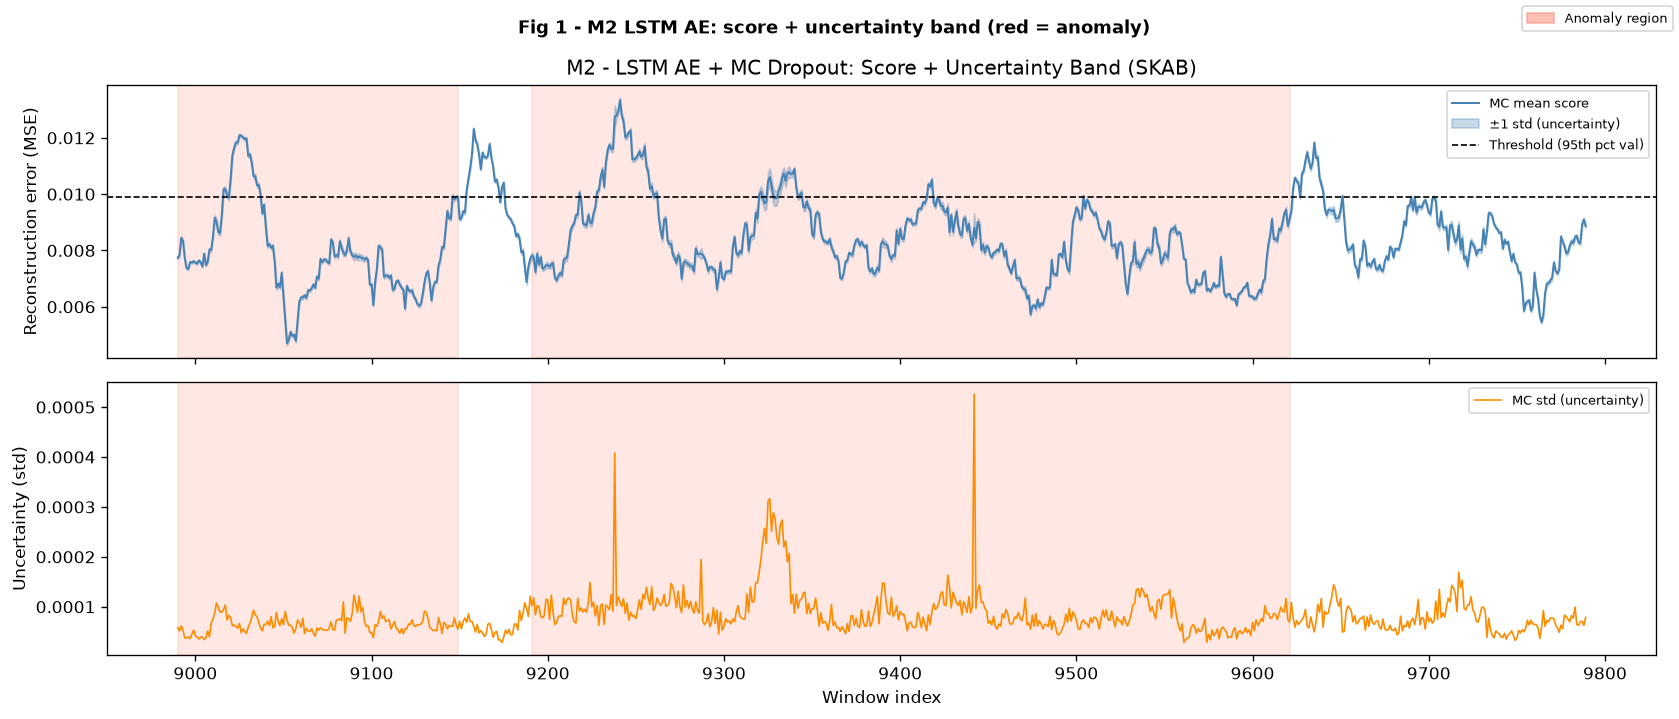

Saved outputs/fig1_m2_score_uncertainty_skab.png


In [20]:
# Fig 1 - score + uncertainty band over time (SKAB)
if "SKAB" in mcd_results:
    y_test  = data["SKAB"]["y_test"]
    mean_s  = mcd_results["SKAB"]["test_mcd"]["mean"]
    std_s   = mcd_results["SKAB"]["test_mcd"]["std"]
    thr     = mcd_results["SKAB"]["det_metrics"]["threshold"]

    transitions = np.where(np.diff(y_test.astype(int)) == 1)[0]
    t0 = int(max(0, transitions[0] - 200)) if len(transitions) else 0
    t1 = int(min(len(y_test), t0 + 800))
    idx = np.arange(t0, t1)

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

    def shade_regions(ax, idx, labels):
        in_a, start = False, None
        for i, lab in zip(idx, labels):
            if lab == 1 and not in_a:
                start, in_a = i, True
            elif lab == 0 and in_a:
                ax.axvspan(start, i, alpha=0.15, color="tomato", zorder=0)
                in_a = False
        if in_a:
            ax.axvspan(start, idx[-1], alpha=0.15, color="tomato", zorder=0)

    ax0 = axes[0]
    ax0.plot(idx, mean_s[t0:t1], color="steelblue", lw=1.2, label="MC mean score")
    ax0.fill_between(
        idx, mean_s[t0:t1] - std_s[t0:t1], mean_s[t0:t1] + std_s[t0:t1],
        alpha=0.30, color="steelblue", label="±1 std (uncertainty)",
    )
    ax0.axhline(thr, color="black", ls="--", lw=1.0,
                label=f"Threshold ({THRESHOLD_PCT}th pct val)")
    shade_regions(ax0, idx, y_test[t0:t1])
    ax0.set_ylabel("Reconstruction error (MSE)")
    ax0.set_title("M2 - LSTM AE + MC Dropout: Score + Uncertainty Band (SKAB)")
    ax0.legend(fontsize=8)

    ax1 = axes[1]
    ax1.plot(idx, std_s[t0:t1], color="darkorange", lw=1.0, label="MC std (uncertainty)")
    shade_regions(ax1, idx, y_test[t0:t1])
    ax1.set_ylabel("Uncertainty (std)")
    ax1.set_xlabel("Window index")
    ax1.legend(fontsize=8)

    from matplotlib.patches import Patch
    fig.legend(handles=[Patch(color="tomato", alpha=0.4, label="Anomaly region")],
               loc="upper right", fontsize=8)
    fig.suptitle("Fig 1 - M2 LSTM AE: score + uncertainty band (red = anomaly)",
                 fontsize=11, fontweight="bold")
    plt.tight_layout()
    path = f"{OUTPUT_DIR}/fig1_m2_score_uncertainty_skab.png"
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved {path}")
else:
    print("SKAB not in results - skipping Fig 1.")

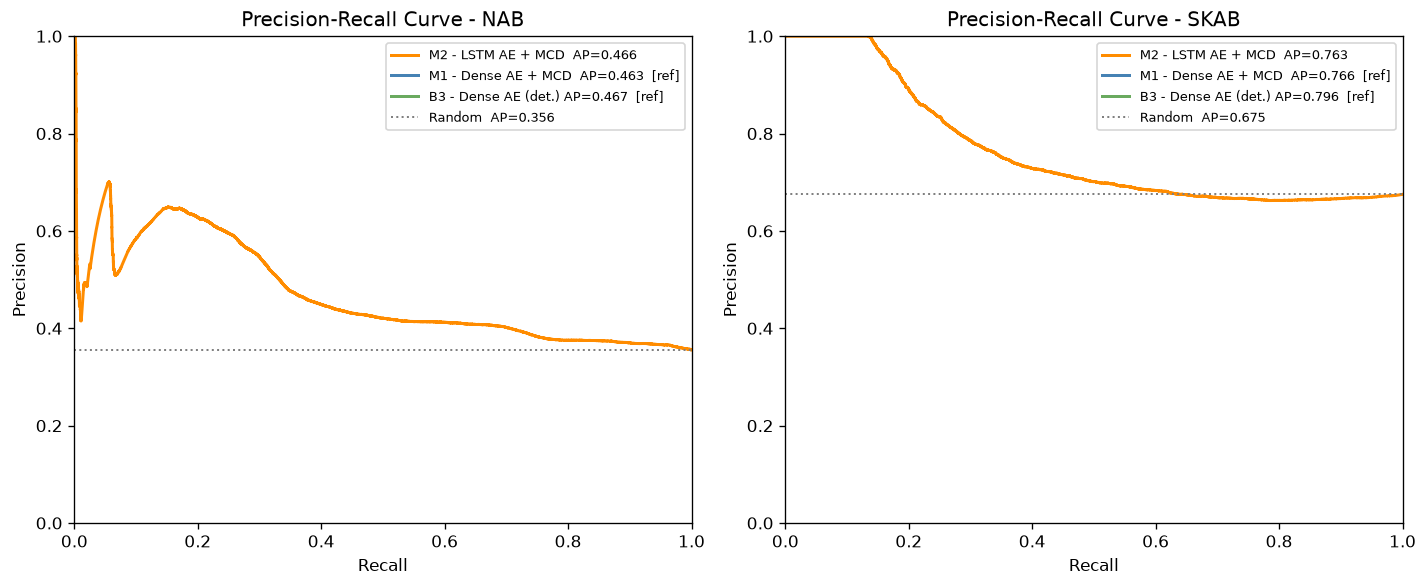

Saved outputs/m2_pr_curves.png


In [21]:
# PR curves - M1 reference + M2 + random baseline
n_ds  = len(mcd_results)
fig, axes = plt.subplots(1, n_ds, figsize=(6 * n_ds, 5))
if n_ds == 1:
    axes = [axes]

for ax, ds_name in zip(axes, sorted(mcd_results.keys())):
    y_test     = data[ds_name]["y_test"]
    mean_score = mcd_results[ds_name]["test_mcd"]["mean"]

    prec, rec, _ = precision_recall_curve(y_test, mean_score)
    m2_ap = mcd_results[ds_name]["det_metrics"]["auc_pr"]
    ax.plot(rec, prec, color="darkorange", lw=1.8,
            label=f"M2 - LSTM AE + MCD  AP={m2_ap:.3f}")

    # M1 reference from saved results
    m1_ap = (baseline_results.get(ds_name, {})
             .get("M1_dense_mcd", {}).get("metrics", {}).get("auc_pr", None))
    if m1_ap:
        ax.plot([], [], color="steelblue", lw=1.8,
                label=f"M1 - Dense AE + MCD  AP={m1_ap:.3f}  [ref]")

    b3_ap = (baseline_results.get(ds_name, {})
             .get("B3_denseae", {}).get("metrics", {}).get("auc_pr", None))
    if b3_ap:
        ax.plot([], [], color="#6aaa5f", lw=1.8,
                label=f"B3 - Dense AE (det.) AP={b3_ap:.3f}  [ref]")

    anom_rate = float(y_test.mean())
    ax.axhline(anom_rate, color="grey", ls=":", lw=1.2,
               label=f"Random  AP={anom_rate:.3f}")

    ax.set_title(f"Precision-Recall Curve - {ds_name}")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

plt.tight_layout()
path = f"{OUTPUT_DIR}/m2_pr_curves.png"
plt.savefig(path, bbox_inches="tight")
plt.show()
print(f"Saved {path}")

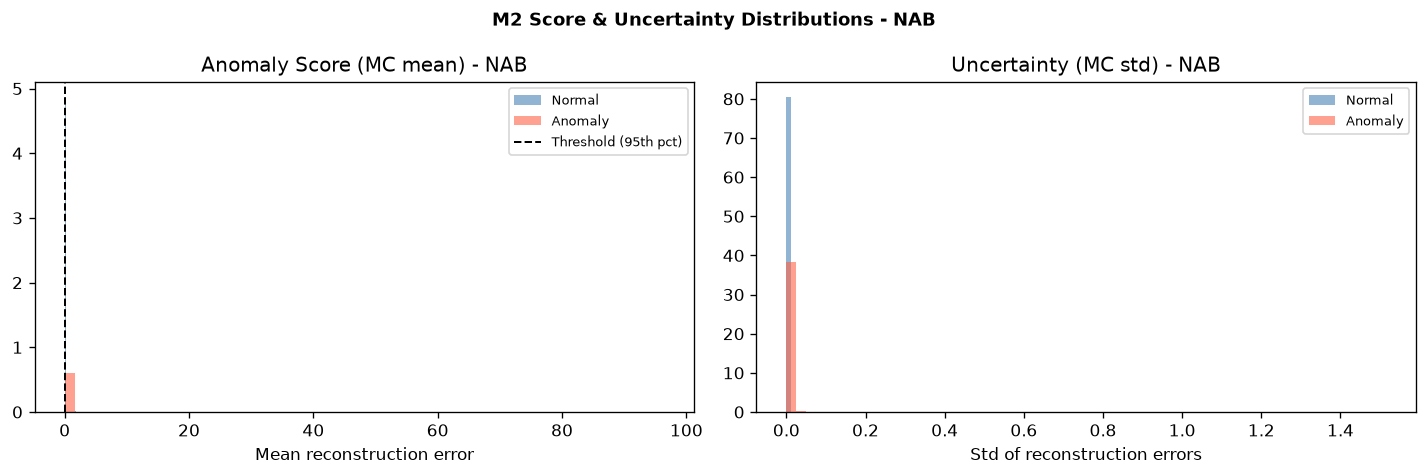

Saved outputs/m2_distributions_nab.png


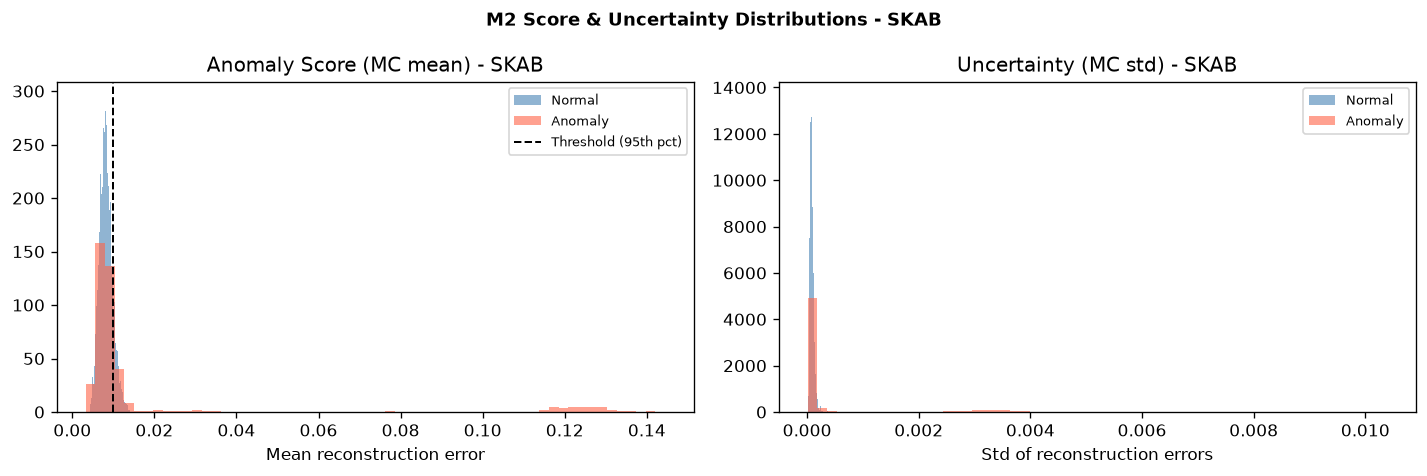

Saved outputs/m2_distributions_skab.png


In [22]:
for ds_name in sorted(mcd_results.keys()):
    y_test     = data[ds_name]["y_test"]
    mean_score = mcd_results[ds_name]["test_mcd"]["mean"]
    std_score  = mcd_results[ds_name]["test_mcd"]["std"]
    thr        = mcd_results[ds_name]["det_metrics"]["threshold"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(mean_score[y_test == 0], bins=60, alpha=0.6, density=True,
                 color="steelblue", label="Normal")
    axes[0].hist(mean_score[y_test == 1], bins=60, alpha=0.6, density=True,
                 color="tomato",    label="Anomaly")
    axes[0].axvline(thr, color="black", ls="--", lw=1.2,
                    label=f"Threshold ({THRESHOLD_PCT}th pct)")
    axes[0].set_title(f"Anomaly Score (MC mean) - {ds_name}")
    axes[0].set_xlabel("Mean reconstruction error")
    axes[0].legend(fontsize=8)

    axes[1].hist(std_score[y_test == 0], bins=60, alpha=0.6, density=True,
                 color="steelblue", label="Normal")
    axes[1].hist(std_score[y_test == 1], bins=60, alpha=0.6, density=True,
                 color="tomato",    label="Anomaly")
    axes[1].set_title(f"Uncertainty (MC std) - {ds_name}")
    axes[1].set_xlabel("Std of reconstruction errors")
    axes[1].legend(fontsize=8)

    fig.suptitle(f"M2 Score & Uncertainty Distributions - {ds_name}",
                 fontsize=11, fontweight="bold")
    plt.tight_layout()
    path = f"{OUTPUT_DIR}/m2_distributions_{ds_name.lower()}.png"
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved {path}")

---
## Section 9 - Save Results

In [23]:
try:
    with open(RESULTS_FILE) as f:
        all_results = json.load(f)
except FileNotFoundError:
    all_results = {}
    print("WARNING: baseline_results.json not found - creating fresh.")

for ds_name, res in mcd_results.items():
    if ds_name not in all_results:
        all_results[ds_name] = {}
    dm = res["det_metrics"]
    hp = res["hp"]
    all_results[ds_name]["M2_lstm_mcd"] = {
        "hp": hp,
        "hidden_dim": LSTM_HIDDEN_DIM,
        "metrics": {
            "auc_pr":    dm["auc_pr"],
            "auroc":     dm["auroc"],
            "f1":        dm["f1"],
            "threshold": dm["threshold"],
            "auroc_unc": res["auroc_unc"],
        },
        "train_losses": res["train_losses"],
        "val_losses":   res["val_losses"],
    }

with open(RESULTS_FILE, "w") as f:
    json.dump(all_results, f, indent=2)

print(f"Results saved → {RESULTS_FILE}")
print("Keys in results file:")
for ds_name, methods in all_results.items():
    print(f"  {ds_name}: {list(methods.keys())}")

Results saved → outputs/baseline_results.json
Keys in results file:
  SKAB: ['B1_zscore', 'B2_isoforest', 'B3_denseae', 'M3_dense_cp', 'M4_lstm_cp', 'M2b_lstm_mcd_lowdrop', 'M1_dense_mcd', 'M2_lstm_mcd']
  NAB: ['B1_zscore', 'B2_isoforest', 'B3_denseae', 'M3_dense_cp', 'M4_lstm_cp', 'M2b_lstm_mcd_lowdrop', 'M1_dense_mcd', 'M2_lstm_mcd']


In [24]:
print("=" * 72)
print("  M2 - LSTM AE + MC Dropout  FINAL SUMMARY")
print("=" * 72)

for ds_name in sorted(mcd_results.keys()):
    res = mcd_results[ds_name]
    dm  = res["det_metrics"]
    hp  = res["hp"]
    b3  = (baseline_results.get(ds_name, {})
           .get("B3_denseae", {}).get("metrics", {}))
    m1  = (baseline_results.get(ds_name, {})
           .get("M1_dense_mcd", {}).get("metrics", {}))

    print(f"\n  {ds_name}")
    print(f"  Best HP : dropout_p={hp['dropout_p']}  "
          f"latent_dim={hp['latent_dim']}  lr={hp['lr']:.0e}  "
          f"hidden_dim={LSTM_HIDDEN_DIM}")
    print(f"  {'Metric':<22} {'B3 (det.)':>12} {'M1 (Dense)':>12} "
          f"{'M2 (LSTM)':>12} {'vs B3':>9} {'vs M1':>9}")
    print(f"  {'─'*78}")

    for key, label in [("auc_pr","AUC-PR"),("auroc","AUROC"),("f1","F1")]:
        b3v  = b3.get(key, float("nan"))
        m1v  = m1.get(key, float("nan"))
        m2v  = dm.get(key, float("nan"))
        d_b3 = m2v - b3v
        d_m1 = m2v - m1v
        print(f"  {label:<22} {b3v:>12.4f} {m1v:>12.4f} {m2v:>12.4f} "
              f"{'+'if d_b3>=0 else ''}{d_b3:>8.4f} "
              f"{'+'if d_m1>=0 else ''}{d_m1:>8.4f}")

    print(f"  {'AUROC(uncertainty)':<22} {'-':>12} "
          f"{m1.get('auroc_unc', float('nan')):>12.4f} "
          f"{res['auroc_unc']:>12.4f} {'-':>9} {'-':>9}")

print("\n" + "=" * 72)
print(f"\n  Plots   → {OUTPUT_DIR}/")
print(f"  Models  → {CKPT_DIR}/")
if PUSH_TO_HUB:
    print(f"  HF Hub  → https://huggingface.co/{MODEL_REPO_ID}/tree/main/checkpoints")
print(f"  Results → {RESULTS_FILE}")
print("=" * 72)

  M2 - LSTM AE + MC Dropout  FINAL SUMMARY

  NAB
  Best HP : dropout_p=0.05  latent_dim=32  lr=2e-03  hidden_dim=64
  Metric                    B3 (det.)   M1 (Dense)    M2 (LSTM)     vs B3     vs M1
  ──────────────────────────────────────────────────────────────────────────────
  AUC-PR                       0.4672       0.4631       0.4663  -0.0009 +  0.0032
  AUROC                        0.6012       0.5934       0.5992  -0.0020 +  0.0058
  F1                           0.3183       0.3182       0.3164  -0.0019  -0.0018
  AUROC(uncertainty)                -       0.5835       0.5858         -         -

  SKAB
  Best HP : dropout_p=0.05  latent_dim=16  lr=1e-03  hidden_dim=64
  Metric                    B3 (det.)   M1 (Dense)    M2 (LSTM)     vs B3     vs M1
  ──────────────────────────────────────────────────────────────────────────────
  AUC-PR                       0.7960       0.7657       0.7632  -0.0328  -0.0025
  AUROC                        0.6105       0.5470       0.5455 